# Day 08. Exercise 01
# Binary classifier. SVM. Decision tree

## 0. Imports

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn import tree
from sklearn.svm import SVC
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler  
from sklearn.linear_model import LogisticRegression

In [2]:
def create_figure(dataset, type, hue1, hue2, t2, X,Y,Z=None):
    fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

    sns.scatterplot(
        x='am', y='pm',
        data=dataset,
        hue=hue1,
        palette={'weekend': "r", 'work': "b"},
        ax=ax1)
    if type == 'linear': ax1.plot(X, Y, color='green', label='decision boundary')
    elif type == 'matrix': ax1.contour(X, Y, Z)
    ax1.legend(loc='best')
    ax1.set_title('Target')

    sns.scatterplot(
        x='am', y='pm',
        data=dataset,
        hue=hue2,
        palette={'weekend': "r", 'work': "b"},
        ax=ax2)
    if type == 'linear': ax2.plot(X, Y, color='green', label='decision boundary')
    elif type == 'matrix': ax2.contour(X, Y, Z)

    ax2.legend(loc='best')
    ax2.set_title(t2)

    plt.tight_layout()
    plt.show()

In [3]:
def boundary(model, df):
    coef1 = model.coef_[0][0]
    coef2 = model.coef_[0][1]

    k = -coef1 / coef2
    c = -model.intercept_[0] / coef2

    X = np.linspace(min(df['am']), max(df['am']), 5)
    Y = k * X + c
    return X,Y

## 1. Preprocessing and logreg visualization

In [4]:
df = pd.read_csv('../data/am_pm.csv')
x = df[['am','pm']]
y = df['target']

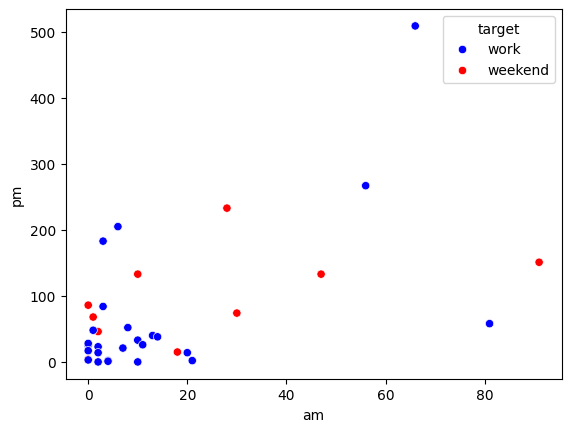

In [5]:
sns.scatterplot(x='am', y='pm', data=df, hue='target', palette={'weekend': "r", 'work': "b"})
plt.show()

In [6]:
model = LogisticRegression(random_state=21, fit_intercept=False)
model.fit(x, y)
y_pred = model.predict(x)

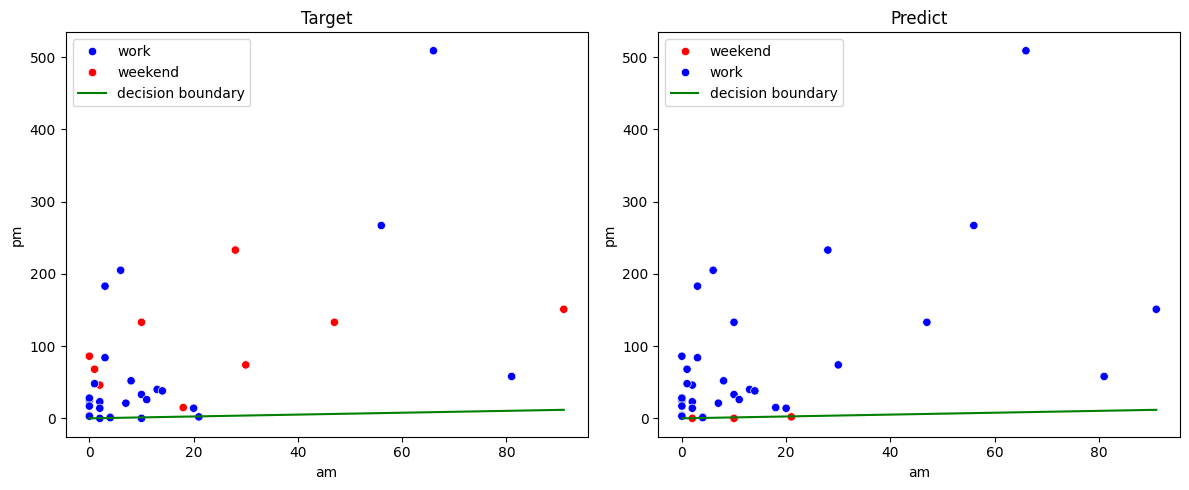

In [7]:
X,Y = boundary(model, df)
create_figure(df, 'linear', 'target', 'predict', 'Predict', X, Y)

## 2. Standardizing and logreg

In [8]:
scaler = StandardScaler()
df[['am','pm']] = scaler.fit_transform(df[['am','pm']])
model.fit(df[['am','pm']], df['target'])

y_pred = model.predict(df[['am','pm']])
df.head()

,date,target,am,pm,predict
0,2020-04-17,work,0.200690,-0.719904,weekend
1,2020-04-18,weekend,-0.655914,-0.071822,work
2,2020-04-19,weekend,0.072199,-0.592251,work
3,2020-04-20,work,-0.613084,-0.513696,work
4,2020-04-21,work,-0.698744,-0.494057,work


In [9]:
print(f'Scaler Accuracy Score: {accuracy_score(y, y_pred)}')
print(f'Naive Accuracy Score: {accuracy_score(y, [df['target'].mode()[0]]*len(df))}')

Scaler Accuracy Score: 0.7428571428571429
Naive Accuracy Score: 0.7142857142857143


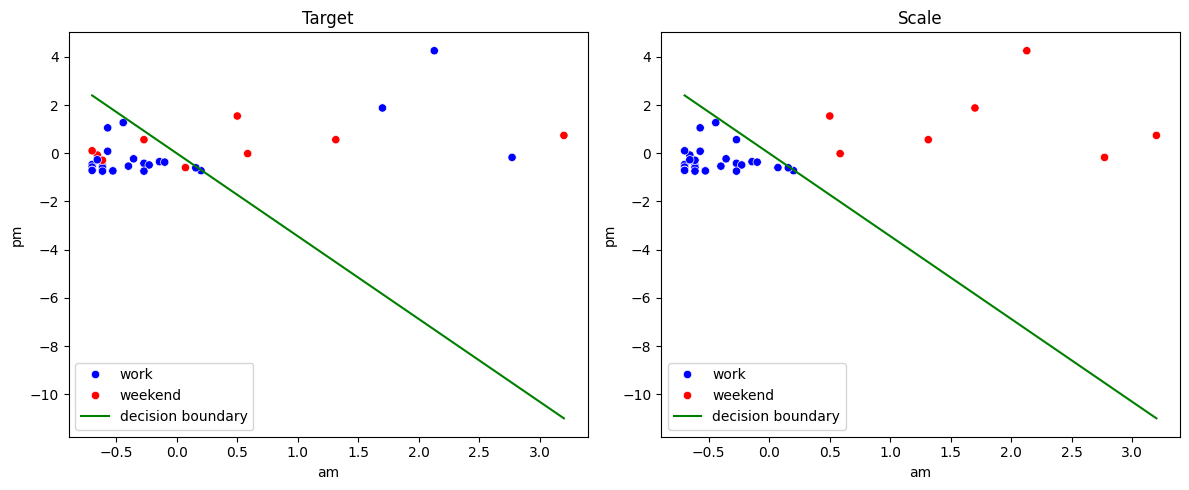

In [10]:
X,Y = boundary(model, df)
create_figure(df, 'linear', 'target', y_pred, 'Scale', X, Y)

## 3. SVM

In [11]:
model = SVC(random_state=42, probability=True, kernel='poly')
x = df[['am','pm']]
Y = df['target'].map({'work': 0, 'weekend': 1})

model.fit(x, Y)
y_pred = model.predict(x)
y_pred = pd.Series(y_pred).map({0:'work', 1:'weekend'})

Accuracy of SVC

In [12]:
accuracy_score(y, y_pred)

0.7428571428571429

In [13]:
def plot():
    x_min, x_max = df['am'].min() - 1, df['am'].max() + 1
    Y_min, y_max = df['pm'].min() - 1, df['pm'].max() + 1

    X, Y = np.meshgrid(np.arange(x_min, x_max, 0.01),
                        np.arange(Y_min, y_max, 0.01))
    Z = model.predict(pd.DataFrame(np.c_[X.ravel(), Y.ravel()], columns=['am', 'pm']))
    Z = Z.reshape(X.shape)
    return X,Y,Z

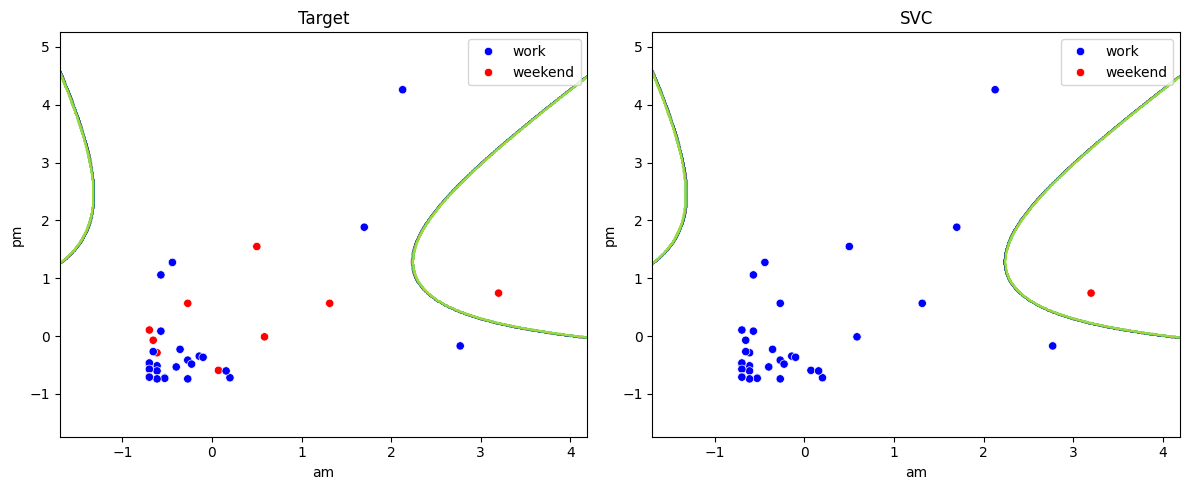

In [14]:
X,Y,Z = plot()
create_figure(df, 'matrix', 'target', y_pred, 'SVC', X, Y, Z)

## 4. Decision tree

In [15]:
for i in range(1,7):
    model = DecisionTreeClassifier(max_depth=i, random_state=42)

    model.fit(df[['am','pm']], df['target'])
    y_pred = model.predict(df[['am','pm']])
    print(f'Accuracy for max_depth == {i}: {accuracy_score(df['target'], y_pred)}')

Accuracy for max_depth == 1: 0.7714285714285715
Accuracy for max_depth == 2: 0.8571428571428571
Accuracy for max_depth == 3: 0.8857142857142857
Accuracy for max_depth == 4: 0.9428571428571428
Accuracy for max_depth == 5: 0.9714285714285714
Accuracy for max_depth == 6: 1.0


In [16]:
model = DecisionTreeClassifier(max_depth=4, random_state=42)
Y = df['target'].map({'work': 0, 'weekend': 1})

model.fit(x, Y)
y_pred = model.predict(x)
y_pred = pd.Series(y_pred).map({0: 'work', 1: 'weekend'})

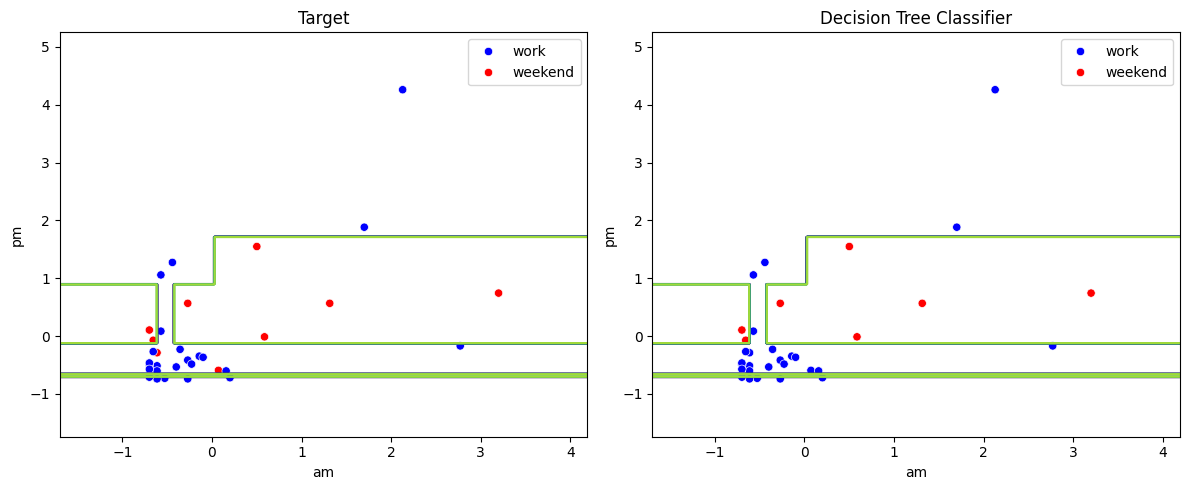

In [17]:
X,Y,Z = plot()
create_figure(df, 'matrix', 'target', y_pred, 'Decision Tree Classifier',X,Y,Z)

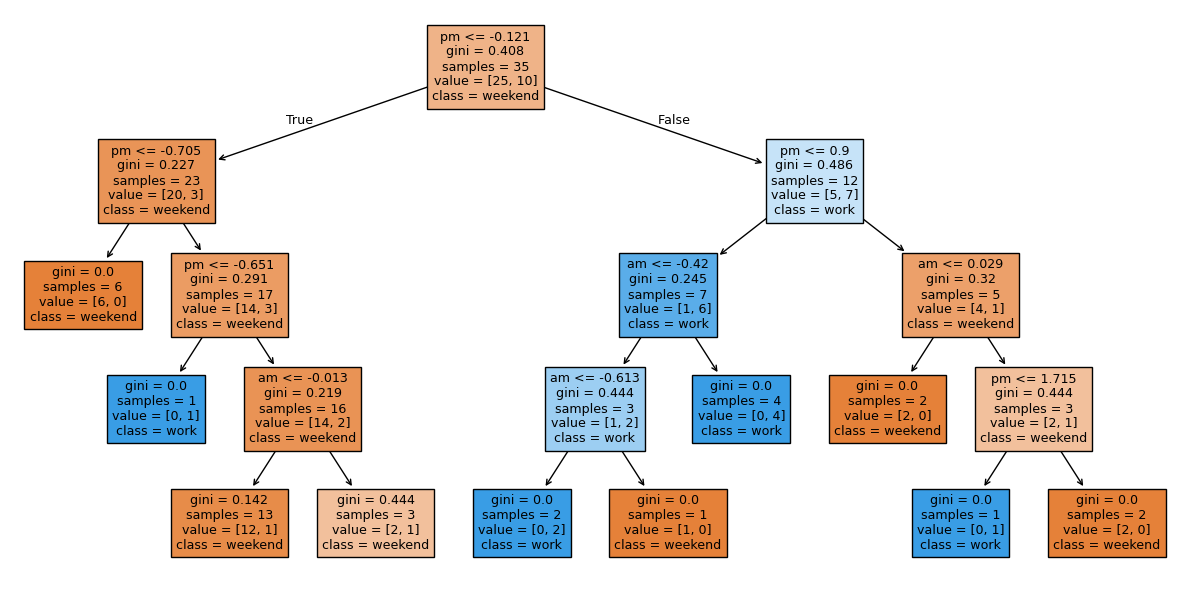

In [18]:
plt.figure(figsize=(12,6))
tree.plot_tree(model, filled=True, feature_names=model.feature_names_in_, class_names=['weekend', 'work'])
plt.tight_layout()
plt.show()

>***Сколько листьев на визуализированном дереве обозначают рабочие дни?***
>
>Ответ: **4**